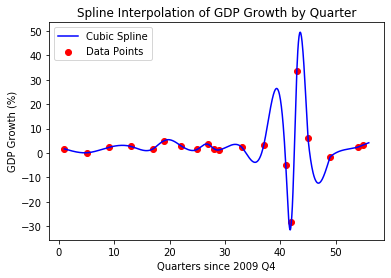

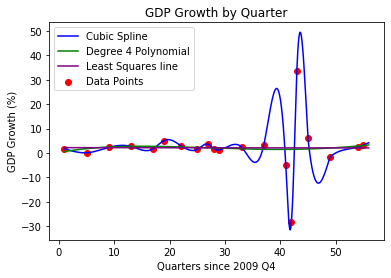

slope of least sqaures: -0.0022232623449566767


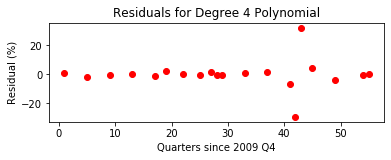

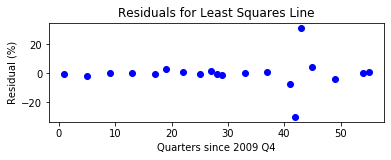

In [36]:
#imports all needed libraries
import numpy as np
import matplotlib.pyplot as plt

def myLeastSquared (X, Y):
    """
    Computes least-squares linear regression
    
    Inputs:
        X: array of x data points
        Y: array of y data points
        
    Outputs:
        m: x coefficient
        c: constant
    """
    sumX = sum(X)
    sumY = sum(Y)
    sumX2 = sum(X*X)
    sumXY = sum(X*Y)
    m = (len(X)*sumXY-sumX*sumY)/(len(X)*sumX2-(sumX**2))
    c = (sumY-m*sumX)/len(X)
    return m,c

def polyFit (X, Y, degree):
    """
    Computes least-squares polynomial fit using normal equations
    
    Inputs:
        X: array of x data points
        Y: array of y data points
        degree: degree of polynomial
    
    Output:
        coefficients: array of polynomial coefficients (lowest to highest)
    """

    n = len(X)
    V = np.zeros((n, degree + 1))
    for i in range(n):
        for j in range(degree + 1):
            V[i, j] = X[i]**j
    VT_V = np.dot(V.T, V)
    VT_Y = np.dot(V.T, Y)
    coefficients = np.linalg.solve(VT_V, VT_Y)
    return coefficients
   
def setup_tridiagonal_matrix(x, y):
    """
    sets up tridiagonal matrix for natural cubic spline
    
    Inputs:
        x: array of x data points
        y: array of y data points
    
    Output:
        A: subdiagonal
        B: main diagonal
        C: superdiagonal
        D: right hand side
    """
    n = len(x)
    h = np.diff(x)
    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]
        B[i - 1] = 2*(h[i-1]+h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6*((y[i+1]-y[i])/h[i]-(y[i]-y[i-1])/h[i-1])
    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    """
    solves tridiagonal system using Thomas Algorithm
    
    Inputs:
        A: subdiagonal
        B: main diagonal
        C: superdiagonal
        D: right hand side
    
    Output:
        x: solution vector
    """
    n = len(b)
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x, y, M, x_eval):
    """
    evaluates cubic spline
    
    Inputs:
        x: array of x data points
        y: array of y data points
        M: vector of 2nd derivatives at data points
        x_eval: array of x data points being evaluated
    
    Output:
        y_eval: array of y data points based on spline and x_eval
    """
    n = len(x)
    y_eval = np.zeros_like(x_eval)
    for j, xe in enumerate(x_eval):
        for i in range(n-1):
            if x[i] <= xe <= x[i+1]:
                break
        h_i = x[i+1] - x[i]
        term1 = M[i] * (x[i+1] - xe)**3 / (6 * h_i)
        term2 = M[i+1] * (xe - x[i])**3 / (6 * h_i)
        term3 = (y[i] - M[i]*h_i**2/6) * (x[i+1] - xe) / h_i
        term4 = (y[i+1] - M[i+1]*h_i**2/6) * (xe - x[i]) / h_i
        y_eval[j] = term1 + term2 + term3 + term4
    return y_eval

#establishes known data points
x = np.array([1,5,9,13,17,19,22,25,27,28,29,33,37,41,42,43,45,49,54,55])
gdp_growth = np.array([1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3])

#gets diagonals and right hand side of tridiagonal matrix, solves it, and puts it in matrix for 2nd derivatives for natural spline
n = len(x)
a,b,c,d = setup_tridiagonal_matrix(x, gdp_growth)
M_internal = thomas_algorithm(a, b, c, d)
M = np.zeros(n)
M[1:-1] = M_internal

#sets up and evaluates points to graph cubic spline
x_eval = np.linspace(1,56,1000)
y_eval = evaluate_spline(x, gdp_growth, M, x_eval)

#gets coefficients for a degree 4 polynomial fit
polyCoefficients = polyFit(x,gdp_growth,4)
y_pred = polyCoefficients[0]+polyCoefficients[1]*x_eval+polyCoefficients[2]*(x_eval**2)+polyCoefficients[3]*(x_eval**3)+polyCoefficients[4]*(x_eval**4)

#gets the residuals between known values and approximate degree 4 polynomial
residual_poly = gdp_growth - (polyCoefficients[0]+polyCoefficients[1]*x+polyCoefficients[2]*(x**2)+polyCoefficients[3]*(x**3)+polyCoefficients[4]*(x**4))

#establishes known data points excluding covid years 2020 Q1 - 2021 Q1
lstsq_x = np.array([1,5,9,13,17,19,22,25,27,28,29,33,37,49,54,55])
lstsq_gdp_growth = np.array([1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-1.6,2.4,3.3])

#gets least squared line for data points excluding covid years
m, k = myLeastSquared(lstsq_x, lstsq_gdp_growth)
y_line = m*x_eval + k

#gets the residuals between known values and approximate least squares line
residual_lstsq = gdp_growth - (m*x + k)

#plotting cubic spline
plt.scatter(x, gdp_growth, color="red", label="Data Points")
plt.plot(x_eval, y_eval, color="blue", label="Cubic Spline")
plt.title('Spline Interpolation of GDP Growth by Quarter')
plt.xlabel('Quarters since 2009 Q4')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.show()

#plotting cubic spline, degree 4 polynomial, and least squares line
plt.scatter(x, gdp_growth, color="red", label="Data Points")
plt.plot(x_eval, y_eval, color="blue", label="Cubic Spline")
plt.plot(x_eval, y_pred, color="green", label="Degree 4 Polynomial")
plt.plot(x_eval, y_line, color="purple", label="Least Squares line")
plt.title('GDP Growth by Quarter')
plt.xlabel('Quarters since 2009 Q4')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.show()

#prints slope
print("slope of least sqaures:", m)

#plots residuals for degree 4 polynomial
plt.subplot(2,1,1)
plt.scatter(x, residual_poly, color="red")
plt.title('Residuals for Degree 4 Polynomial')
plt.xlabel('Quarters since 2009 Q4')
plt.ylabel('Residual (%)')
plt.show()

#plots residuals for least squares line
plt.subplot(2,1,2)
plt.scatter(x, residual_lstsq, color="blue")
plt.title('Residuals for Least Squares Line')
plt.xlabel('Quarters since 2009 Q4')
plt.ylabel('Residual (%)')
plt.show()

COE 311k GDP Growth Rate Midterm Project Write Up
(bullets used to signify paragraph)

- The set of data being used is the GDP growth rate by quarter, provided by the U.S. Bureau of Economic Analysis (BEA). This rate is the seasonally adjusted annual rate (SAAR) of real GDP growth, measured in percent. Not every quarter is given and the data spans from 2010 to 2023, with the Covid-impacted quarters, 2020 Q1 through 2021 Q1, omitted for the least squares linear analysis. We will be applying a natural cubic spline interpolation and fitting both a degree 4 polynomial and line to the data.
- For the cubic spline interpolation, we are finding a cubic function to approximate the space between each knot. Each of these pieces has 4 unknowns, and since we have 20 known points, there are 19 cubic functions we need to find. This results in 76 unknowns. In order to maintain continuity, the spline interpolations must equal the knots at their endpoints, their derivatives must be equal to the other spline beginning or ending at the same knot, and their second derivatives must be equal to the other spline beginning or ending at the same knot. Additionally, for the interpolation to be natural, the second derivatives at the endpoints must equal zero. This results in 76 total equations, and the same number of unknowns meaning it is able to be solved. Doing so and plotting these splines we get this plot. (1st printed plot) Looking at the plot, we can tell that it is visually smooth and passes through all of the data points. It also appears relatively reasonable because it remains mostly true to the data points without stretching too much without being prompted to by known values. However, this type of graph can come with limitations. The Runge Phenomenon describes how for functions of higher degree used to approximate a data set, large oscillations can occur near or beyond the edges. One of the benefits for exact interpolation is that it gives a better approximation between the known data, but it is very susceptible to outliers since it fully weighs every data point. This can limit the numeric stability of these functions in certain situations. For this case, a weighted least squares would likely be preferable, since the outlier quarters that are affected by covid will significantly affect the cubic spline interpolation, but a weighted least squares would be able to adjust to ignore them more, giving a better approximation for the rest of the data. However, for the years affected by covid, a cubic spline would better approximate them because they did happen and the cubic spline would not ignore them and would weigh them significantly.
- By also approximating a degree 4 polynomial and least squares line for the data set alongside the cubic spline we get the following graph. (2nd printed plot) As shown by the plot, the degree 4 polynomial approximates the overall trend of the data better than the cubic spline, but the cubic spline approximates near specific data points better. This is because, as mentioned before, the cubic spline creates a curve between every data point, resulting in a significant impact of each point. However, the degree 4 polynomial is less susceptible to the influence of outliers, since it creates one function to approximate everything, resulting in a better overall approximation. This shows a trade off between approximation and interpolation, with interpolation getting a better approximation near specific data points and approximation getting a better approximation of the overall trend of the data, ignoring outliers more. 
- From our least squares line, we get a slope of -0.0022232623449566767, meaning that the GDP growth decreases by roughly that amount each quarter. A linear trend would make economic sense for this data set, since barring significant external factors, the GDP grows by about the same percentage each quarter. For a linear approximation to make sense, we assume that the GDP growth changes by about the same amount each quarter, which is relatively true historically.
- Below is the residual graphs for both a degree 4 polynomial and a least squares line approximation:
    (3rd and 4th plots printed)
- From these plots, we can see that both approximations have similar deficiencies when approximating the data, especially around the covid quarters. They are both off by more than 20% GDP growth during these times, demonstrating the ability to ignore outliers to gather the overall trend. Since they have very similar residual results for the given data, I would recommend a least squares line if quarters outside of the time frame given want to be approximated because the degree 4 polynomial will begin to oscillate and diverge more the further from the data we get. For a policy maker who needs to approximate a data point between known quarters, I would recommend a cubic spline, since it accounts for every data point better. Since none of the data can truly be ignored, the cubic spline gives a better approximation for information between two points. This is evident by the covid years, which the two approximations have very large residuals for known data, but the cubic spline will account for these large bumps and falls. It is much more sensitive to outliers, which is beneficial if we know all the data is true and correct. Big O notation describes how the computational cost of an algorithm grows as the number of data points, n, increases, focusing on how the algorithm scales rather than the exact runtime. In this case, all three methods have construction times on the order of O(n). The cubic spline requires solving a tridiagonal system, which can be done efficiently in linear time. Both the polynomial fit and linear regression also require linear time to compute their coefficients and constant time to evaluate. Because all methods are similarly efficient computational complexity does not change the recommendation, leaving my recommendation as the cubic spline for interpolating the data, and a linear approximation for gathering the overall trend.
- For interpolating the data, and gathering information about data between points, cubic spline performs the best. Cubic spline is very susceptible to outliers, which is beneficial if the data is true and adjusting fully for these outliers is necessary. However, this type of function falls victim to both data noise and extrapolating data. It can not be used to figure out information outside of the bounds of the data set, and noise in the data causes the function to wrongly account for it. Trend analysis is typically best done by a polynomial approximation, but in this case, a linear function works best. One issue with polynomial approximation is overfitting, which is when too high of a degree polynomial is used to approximate the data causing oscillation and lack of stability beyond the edges. Since the residuals were similar for both a linear and degree 4 polynomial, the smaller degree function should be used to approximate the data in order to reduce the straying beyond the bounds of the data.